# ResearchLM

## Load documents

In [3]:
import os
import glob
import numpy as np
import tiktoken
from dotenv import load_dotenv
from IPython.display import display, Markdown

In [4]:
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from sklearn.manifold import TSNE

c:\Users\admin\Desktop\Projects\AI_ML_DATASCIENCE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
MODEL = "llama-3.1-8b-instant"

load_dotenv(override=True)
groq_api_key = os.getenv('GROQ_API_KEY')
if groq_api_key:
    print(f"GROQ API Key exists and begins {groq_api_key[:8]}")
else:
    print("GROQ API Key not set")


GROQ API Key exists and begins gsk_tGmX


In [6]:
def get_pdf_files(
    knowledge_base_path="./data/**/*.pdf"
):

    files = glob.glob(
        knowledge_base_path,
        recursive=True
    )

    print(f"Found {len(files)} PDF files")

    return files

In [7]:
pdf_files = get_pdf_files()

Found 4 PDF files


In [8]:
def count_total_characters(pdf_files):

    total_characters = 0

    for file_path in pdf_files:

        loader = PyPDFLoader(file_path)
        pages = loader.load()

        for page in pages:
            total_characters += len(page.page_content)

    print(
        f"Total characters in knowledge base: "
        f"{total_characters:,}"
    )

    return total_characters

In [9]:
count_total_characters(pdf_files)

Total characters in knowledge base: 202,241


202241

In [10]:
import os
import glob
from tqdm.auto import tqdm

def load_documents(knowledge_base_path="./data/**/*.pdf"):
    pdf_files = glob.glob(knowledge_base_path, recursive=True)
    documents = []

    # Add tqdm around the pdf_files list
    for file_path in tqdm(pdf_files, desc="Parsing PDF Files"):
        loader = PyPDFLoader(file_path)
        docs = loader.load()

        for doc in docs:
            doc.metadata["doc_type"] = "research_paper"
            doc.metadata["file_name"] = os.path.basename(file_path)
            documents.append(doc)

    print(f"Loaded {len(documents)} pages")
    return documents

# Execute the updated loader
raw_documents = load_documents()


Parsing PDF Files: 100%|██████████| 4/4 [00:06<00:00,  1.69s/it]

Loaded 53 pages


In [11]:
raw_documents[0]

Document(metadata={'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2016-05-23T00:19:15+00:00', 'author': '', 'keywords': '', 'moddate': '2016-05-23T00:19:15+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-2.3-1.40.12 (TeX Live 2011) kpathsea version 6.0.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': './data\\1409.0473v7.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'doc_type': 'research_paper', 'file_name': '1409.0473v7.pdf'}, page_content='Published as a conference paper at ICLR 2015\nNEURAL MACHINE TRANSLATION\nBY JOINTLY LEARNING TO ALIGN AND TRANSLATE\nDzmitry Bahdanau\nJacobs University Bremen, Germany\nKyungHyun Cho Y oshua Bengio ∗\nUniversit´e de Montr´eal\nABSTRACT\nNeural machine translation is a recently proposed approach to machine transla-\ntion. Unlike the traditional statistical machine translation, the neural machine\ntranslation aims at building a single neural network that can be jointly t

## Phase 1 - Parent-Child Chunking

In [12]:
import os
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_classic.storage import InMemoryStore

# 1. Initialize your embedding model
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# 2. Configure the dual-layer splitters
# Parent chunks provide the broad context to the LLM
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)

# Child chunks provide high-precision semantic matching in the vector space
child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)

# 3. Set up the storage layers
# The vectorstore holds the small embedded child chunks
db_name = "advanced_vector_db"
if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma(
    collection_name="split_parents", 
    embedding_function=embeddings, 
    persist_directory=db_name
)

# The InMemoryStore holds the large raw text parent chunks
store = InMemoryStore()

# 4. Initialize the advanced retriever
retriever = ParentDocumentRetriever(
    vectorstore=vectorstore,
    docstore=store,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

# 5. Ingest the documents with tqdm batching
batch_size = 5 # Adjust based on your system RAM; 5 pages at a time is safe

# Calculate total batches for tqdm
total_batches = (len(raw_documents) + batch_size - 1) // batch_size

for i in tqdm(range(0, len(raw_documents), batch_size), desc="Ingesting to Vector Database"):
    batch = raw_documents[i : i + batch_size]
    retriever.add_documents(batch)

print(f"Successfully processed {len(raw_documents)} raw document pages into hierarchical chunks.")

Ingesting to Vector Database: 100%|██████████| 11/11 [00:12<00:00,  1.14s/it]

Successfully processed 53 raw document pages into hierarchical chunks.


In [13]:
# Run a test query
test_query = "How the Navigable Small World works?"
retrieved_docs = retriever.invoke(test_query)

# Check the length of the retrieved context. 
# It should be close to your parent_splitter chunk_size (~2000 characters), 
# proving it pulled the parent, not just the 400-character child.
print(f"Retrieved {len(retrieved_docs)} parent chunks.")
print(f"Length of top chunk: {len(retrieved_docs[0].page_content)} characters.")

Retrieved 4 parent chunks.
Length of top chunk: 1933 characters.


In [14]:
print(retrieved_docs[1])

page_content='IEEE TRANSACTIONS ON JOURNAL NAME,  MANUSCRIPT ID 1 
 
Efficient and robust approximate nearest 
neighbor search using Hierarchical Navigable 
Small World graphs  
Yu. A. Malkov, D. A. Yashunin 
Abstract — We present a new approach for the approximate K -nearest neighbor search based on navigable small world 
graphs with controllable hierarchy (Hierarchical NSW, HNSW). The proposed solution is fully graph-based, without any need for 
additional search structures, which are typically used at the coarse search stage of the most proximity graph techniques. 
Hierarchical NSW incrementally builds a multi-layer structure consisting from hierarchical set of proximity graphs (layers) for 
nested subsets of the stored elements. The maximum layer in which an element is present is selected randomly with an 
exponentially decaying probability distribution. This allows producing graphs similar to the previously studied Navigable Sma ll 
World (NSW) struc tures while additionally havin

## Phase 2 - Hybrid Search (BM25 + Dense) + Re-ranker

In [15]:
# pip install rank_bm25 sentence-transformers
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

# --- Step 1: Initialize the Sparse Retriever (Keyword Search) ---
# We build the BM25 retriever using the raw_documents loaded in Phase 1
bm25_retriever = BM25Retriever.from_documents(raw_documents)
bm25_retriever.k = 5 # Retrieve the top 5 keyword matches

# --- Step 2: Prepare the Dense Retriever (Semantic Search) ---
# We use the 'retriever' we built in Phase 1 (your ParentDocumentRetriever)
dense_retriever = retriever 
dense_retriever.search_kwargs = {"k": 5} # Retrieve the top 5 semantic matches

# --- Step 3: Combine them using Hybrid Search (Ensemble) ---
# The EnsembleRetriever uses RRF to fuse the ranked lists.
# Weights determine the bias. [0.5, 0.5] means equal priority.
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.5, 0.5]
)

# --- Step 4: Initialize the Cross-Encoder Re-ranker ---
# BAAI/bge-reranker-base is highly optimized for English retrieval tasks.
# cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")
cross_encoder = HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

# Set top_n=3 to ensure only the 3 most strictly relevant chunks are sent to the LLM.
# This saves context window tokens and prevents the LLM from getting distracted.
compressor = CrossEncoderReranker(model=cross_encoder, top_n=3)

# --- Step 5: Wrap the pipeline into the final Advanced Retriever ---
advanced_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=hybrid_retriever
)

print("Phase 2: Hybrid Search + Re-ranker successfully initialized!")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5466.62it/s]


Phase 2: Hybrid Search + Re-ranker successfully initialized!


In [16]:
# Test the advanced retriever
test_query = "How the Navigable Small World works?"
compressed_docs = advanced_retriever.invoke(test_query)

print(f"Final chunks passed to LLM: {len(compressed_docs)}")
for i, doc in enumerate(compressed_docs):
    print(f"\n--- Rank {i+1} ---")
    print(f"Content: {doc.page_content[:500]}")
    print(f"Length: {len(doc.page_content)}")
    print(f"Relevance Score: {doc.metadata.get('relevance_score', 'N/A')}")
    print(f"Source: {doc.metadata.get('file_name')}")

Final chunks passed to LLM: 3

--- Rank 1 ---
Content: the greedy graph r outing are known as the navigable 
small world networks  [31, 32] . Such networks are an i m-
portant topic of complex network theory aiming at u n-
derstanding of underlying mechanisms of real-life ne t-
works formation in order to apply them for appli cations 
of scalable routing [32, 35, 36]  and distributed similarity 
search [25, 26, 30, 37-40].  
The first works to consider spatial models of navigable 
networks were done by J.  Kleinberg [31, 41] as social ne t-
work mod
Length: 1955
Relevance Score: N/A
Source: 1603.09320v4.pdf

--- Rank 2 ---
Content: that use auxiliary algorithms applicable only for vector 
data (such as kd -trees [18, 19] and product 
quantization [10]) to find better candidates for the enter 
nodes by doing a coarse search.  
In [25, 26, 30]  authors proposed a proximity graph 
K-ANNS algorithm called Navigable Small World (NSW, 
also known as Metricized Small World, MSW), which 
utili

## LLM Generation

In [17]:
llm = ChatGroq(temperature=0.7, model_name=MODEL)

In [41]:
SYSTEM_PROMPT_TEMPLATE = """
You are an expert AI research assistant specializing in synthesizing and analyzing academic literature.

Your sole task is to provide technically precise, comprehensive, and objective answers to the user's question using ONLY the provided context blocks. 

---

### STRICT OPERATIONAL DIRECTIVES:
1. **Zero External Knowledge:** Rely entirely on the provided context. Never introduce outside facts, industry assumptions, or extrapolated theories.
2. **Anti-Hallucination Guardrail:** If the exact answer cannot be fully constructed using the provided context, state exactly: "Not enough information available in the provided documents." Do not attempt to bridge gaps with speculation.
3. **Seamless In-Text Citations:** Every claim, fact, or metric you state MUST be immediately followed by an inline citation referencing its source file name and page/section number if available in the context metadata.
4. **Contradiction Resolution:** If different papers provide conflicting information on the same topic, explicitly highlight the variance (e.g., "Paper A states X, whereas Paper B finds Y").
5. **No Meta-Language:** Do not use conversational filler or phrases that reference the system architecture, such as "Based on the context provided," "According to the text," or "The documents show." Jump directly into the factual analysis.

---

### CITATION FORMAT EXAMPLE:
"The Transformer architecture replaces recurrent layers entirely with stacked self-attention mechanisms, significantly reducing training times. However, localized context retention can still vary depending on positional encoding choices [Source: Transformer_Analysis.pdf]."

---

### CONTEXT:
{context}

### QUESTION:
{question}

### ANSWER:
"""

In [42]:
from langsmith import traceable

@traceable()
def answer_question(question: str, history=None):

    # Retrieve docs using the new Hybrid + Reranker pipeline
    docs = advanced_retriever.invoke(question)

    # Build context with metadata
    context_parts = []

    for i, doc in enumerate(docs, start=1):
        source = doc.metadata.get(
            "file_name",
            "Unknown Source"
        )
        page = doc.metadata.get(
            "page",
            "Unknown Page"
        )
        chunk_text = f"""
        Document [{i}]
        Source: {source}
        Page: {page}

        Content:
        {doc.page_content}
        """
        context_parts.append(chunk_text)
    context = "\n\n".join(context_parts)
    
    # Create prompt
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(context=context, question=question)
    
    # Generate response
    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=question)
    ])

    return response.content

In [43]:
response = answer_question("How the Navigable Small World works?")

In [44]:
display(Markdown(response))

The Navigable Small World (NSW) graph is constructed via consecutive insertion of elements in random order by bidirectionally connecting them to the M closest neighbors from the previously inserted elements [25, 26, 30, 31, 32]. The M closest neighbors are found using the structure's search procedure, a variant of a greedy search from multiple random enter nodes [26]. 

Links to the closest neighbors of the elements inserted in the beginning of the construction later become bridges between the network hubs that keep the overall graph connectivity and allow the logarithmic scaling of the number of hops during greedy routing [26]. The construction phase of the NSW structure can be efficiently parallelized without global synchronization and without measurable effect on accuracy [26], being a good choice for distributed search systems [26].

## Phase 3 - Production-Level Evaluation using Ragas.

In [ ]:
# import pandas as pd
# from datasets import Dataset
# from ragas import evaluate
# from ragas.metrics import (
#     faithfulness, 
#     answer_relevancy, 
#     context_precision, 
#     context_recall
# )

# # --- Step 1: Define your Evaluation Dataset ---
# # In a real production system, you'd pull this from a CSV of past user queries.
# eval_questions = [
#     "What is the methodology used in YOLO?",
#     "What is the architecture of the Transformer model?"
# ]

# # Ground truths are required for 'context_recall' (did we find everything we needed?)
# eval_ground_truths = [
#     "YOLO frames object detection as a single regression problem, straight from image pixels to bounding box coordinates and class probabilities.",
#     "The Transformer relies entirely on an attention mechanism, dispensing with recurrence and convolutions, using stacked self-attention and point-wise, fully connected layers."
# ]

# answers = []
# contexts = []

# # --- Step 2: Run the Pipeline to Gather Data ---
# print("Running pipeline to gather generation and retrieval data...")

# for q in eval_questions:
#     # 1. Get the exact chunks the retriever pulled
#     retrieved_docs = advanced_retriever.invoke(q)
#     context_list = [doc.page_content for doc in retrieved_docs]
#     contexts.append(context_list)
    
#     # 2. Get the final LLM generation
#     # Make sure your answer_question function is using advanced_retriever!
#     llm_answer = answer_question(q) 
#     answers.append(llm_answer)

# # --- Step 3: Format Data for Ragas ---
# data = {
#     "user_input": eval_questions,    
#     "response": answers,             
#     "retrieved_contexts": contexts,  
#     "reference": eval_ground_truths  
# }
# dataset = Dataset.from_dict(data)

# # --- Step 4: Run the Evaluation (Updated for Groq & HuggingFace) ---
# print("Evaluating pipeline performance using Ragas...")
# result = evaluate(
#     dataset,
#     metrics=[
#         faithfulness,      
#         answer_relevancy,  
#         context_precision, 
#         context_recall     
#     ],
#     llm=llm,              
#     embeddings=embeddings 
# )

# # Convert to a clean Pandas DataFrame for easy viewing
# df_results = result.to_pandas()
# display(df_results)

C:\Users\admin\AppData\Local\Temp\ipykernel_18400\1797848271.py:4: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
C:\Users\admin\AppData\Local\Temp\ipykernel_18400\1797848271.py:4: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
C:\Users\admin\AppData\Local\Temp\ipykernel_18400\1797848271.py:4: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
C:\Users\admin\AppData\Local\Temp\ipykernel_18

Running pipeline to gather generation and retrieval data...
Evaluating pipeline performance using Ragas...


Evaluating:  12%|█▎        | 1/8 [00:01<00:09,  1.40s/it]LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[1]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
Evaluating:  62%|██████▎   | 5/8 [02:51<01:49, 36.46s/it]Exception raised in Job[4]: TimeoutError()
Exception raised in Job[7]: TimeoutError()
Exception raised in Job[3]: TimeoutError()
Evaluating: 100%|██████████| 8/8 [03:00<00:00, 22.51s/it]


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,What is the methodology used in YOLO?,[making predictions. Unlike sliding window and...,The YOLO (You Only Look Once) methodology invo...,YOLO frames object detection as a single regre...,1.0,NaN,1.0,NaN
1,What is the architecture of the Transformer mo...,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows a stacked...,The Transformer relies entirely on an attentio...,NaN,0.906689,1.0,NaN


## Evaluation using Langsmith
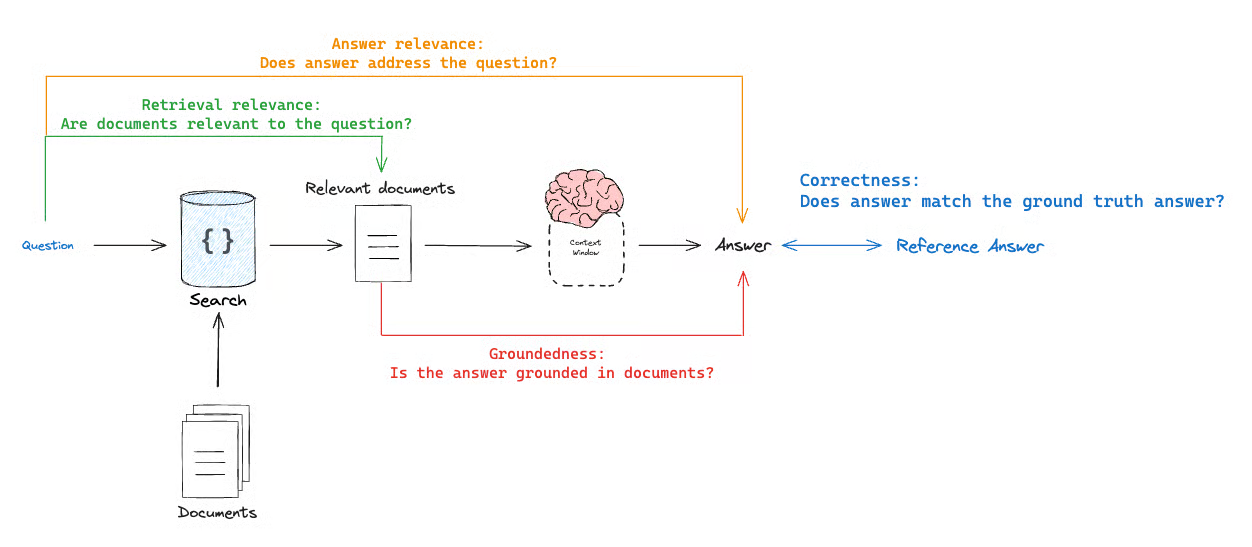

In [45]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_TRACING_V2"] = "true"

In [46]:
import os
from langsmith import Client, evaluate
from langsmith.evaluation import StringEvaluator

# Initialize the LangSmith Client
client = Client()

# --- Step 1: Define your Evaluation Data ---
eval_questions = [
    "What is the methodology used in YOLO?",
    "What is the architecture of the Transformer model?",
    "How does the YOLO system define the confidence score for a bounding box prediction?",
    "What is the main difference between the RNNsearch model and the basic encoder-decoder approach for machine translation?",
    "Why does the Transformer model scale its dot-product attention?",
    "What is the purpose of positional encoding in the Transformer architecture?",
    "How does the Hierarchical Navigable Small World (HNSW) algorithm improve upon the base NSW structure's routing process?"
]

eval_ground_truths = [
    "YOLO frames object detection as a single regression problem, straight from image pixels to bounding box coordinates and class probabilities. The system divides the input image into an S x S grid. If the center of an object falls into a grid cell, that cell is responsible for predicting B bounding boxes and their confidence scores, alongside C conditional class probabilities. A single convolutional neural network simultaneously extracts features and predicts these multiple bounding boxes and class probabilities directly from full images in one evaluation.",
    
    "The Transformer is an encoder-decoder architecture that eschews recurrence and convolutions entirely, relying solely on an attention mechanism to draw global dependencies between input and output. Both the encoder and decoder are composed of a stack of N=6 identical layers. The encoder layers contain two sub-layers: a multi-head self-attention mechanism and a position-wise fully connected feed-forward network. The decoder contains these two sub-layers plus a third sub-layer that performs multi-head attention over the output of the encoder stack. All sub-layers employ residual connections followed by layer normalization.",
   
    "The confidence scores reflect how confident the model is that the box contains an object and how accurate it thinks the predicted box is. Formally, YOLO defines confidence as Pr(Object) * IOU_pred^truth. If no object exists in that cell, the confidence score should be zero; otherwise, the confidence score equals the intersection over union (IOU) between the predicted box and the ground truth.",
    
    "The most important distinguishing feature of the RNNsearch approach from the basic encoder-decoder is that it does not attempt to encode a whole input sentence into a single fixed-length vector. Instead, it encodes the input sentence into a sequence of vectors and chooses a subset of these vectors adaptively while decoding the translation. This frees the neural translation model from having to squash all the information of a source sentence into a fixed-length vector, allowing it to cope better with long sentences.",
    
    "For large values of the key dimension (dk), dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients. To counteract this effect and maintain stable gradients, the Transformer scales the dot products by 1/sqrt(dk).",
    
    "Because the Transformer model contains no recurrence and no convolution, it must inject information about the relative or absolute position of the tokens in the sequence to make use of the order of the sequence. To achieve this, positional encodings are added to the input embeddings at the bottoms of the encoder and decoder stacks. In the Transformer, these encodings are generated using sine and cosine functions of different frequencies.",
    
    "The HNSW algorithm improves routing by separating the links according to their length scale into different layers and then searching in a multilayer graph. In this structure, the search starts from the upper layer which has only the longest links, greedily traversing until a local minimum is reached. After that, the search switches to the lower layer with shorter links, restarts from the local minimum of the previous layer, and repeats the process. This multilayer approach evaluates only a fixed portion of connections independent of network size, allowing logarithmic scalability."
]

# --- Step 2: Create a LangSmith Dataset ---
dataset_name = "RAG_Evaluation_Dataset_2"

# Check if dataset exists to avoid duplicating, otherwise create it
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(
        dataset_name=dataset_name,
        description="Dataset for evaluating RAG pipeline on Research Papers."
    )
    
    # Upload the questions (inputs) and ground truths (outputs) to LangSmith
    client.create_examples(
        inputs=[{"question": q} for q in eval_questions],
        outputs=[{"reference": ref} for ref in eval_ground_truths],
        dataset_id=dataset.id,
    )
    print(f"Dataset '{dataset_name}' created.")
else:
    print(f"Dataset '{dataset_name}' already exists.")

Dataset 'RAG_Evaluation_Dataset_2' already exists.


In [47]:
def run_rag_pipeline(inputs: dict) -> dict:
    """
    Wrapper function that takes dataset inputs and returns your pipeline's outputs.
    """
    question = inputs["question"]
    
    # 1. Get the exact chunks the retriever pulled
    retrieved_docs = advanced_retriever.invoke(question)
    context_list = [doc.page_content for doc in retrieved_docs]
    context_str = "\n".join(context_list)
    
    # 2. Get the final LLM generation
    llm_answer = answer_question(question)
    
    # Return a dictionary containing the answer and the retrieved contexts
    return {
        "answer": llm_answer,
        "contexts": context_str # Passed to evaluators to check context utilization
    }

In [48]:
from typing_extensions import Annotated, TypedDict
from langchain_groq import ChatGroq
from langsmith import evaluate

# Initialize the Judge LLM

judge_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

# ==========================================
# 1. Correctness: Response vs Reference Answer
# ==========================================
class CorrectnessGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    correct: Annotated[bool, ..., "True if the answer is correct, False otherwise."]

correctness_instructions = """You are a teacher grading a quiz. You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER, and the STUDENT ANSWER. 
Here is the grade criteria to follow:
(1) Grade the student answers based ONLY on their factual accuracy relative to the ground truth answer.
(2) Ensure that the student answer does not contain any conflicting statements.
(3) It is OK if the student answer contains more information than the ground truth answer, as long as it is factually accurate relative to the ground truth answer.

Correctness:
A correctness value of True means that the student's answer meets all of the criteria.
A correctness value of False means that the student's answer does not meet all of the criteria.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 
Avoid simply stating the correct answer at the outset.
You must respond with a valid JSON object matching the requested schema."""

correctness_grader = judge_llm.with_structured_output(CorrectnessGrade)

def correctness(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """An evaluator for RAG answer accuracy."""
    # reference_outputs['reference'] aligns with the dataset schema we defined earlier
    answers = f"""QUESTION: {inputs['question']}
GROUND TRUTH ANSWER: {reference_outputs['reference']}
STUDENT ANSWER: {outputs['answer']}"""
    
    grade = correctness_grader.invoke([
        {"role": "system", "content": correctness_instructions},
        {"role": "user", "content": answers}
    ])
    return grade["correct"]

In [49]:
# ==========================================
# 2. Relevance: Response vs Input
# ==========================================
class RelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "Provide the score on whether the answer addresses the question"]

relevance_instructions = """You are a teacher grading a quiz. You will be given a QUESTION and a STUDENT ANSWER. 
Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION
(2) Ensure the STUDENT ANSWER helps to answer the QUESTION

Relevance:
A relevance value of True means that the student's answer meets all of the criteria.
A relevance value of False means that the student's answer does not meet all of the criteria.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 
Avoid simply stating the correct answer at the outset.
You must respond with a valid JSON object matching the requested schema."""

relevance_grader = judge_llm.with_structured_output(RelevanceGrade)

def relevance(inputs: dict, outputs: dict) -> bool:
    """An evaluator for RAG answer helpfulness."""
    answer = f"QUESTION: {inputs['question']}\nSTUDENT ANSWER: {outputs['answer']}"
    
    grade = relevance_grader.invoke([
        {"role": "system", "content": relevance_instructions},
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]

In [50]:
# ==========================================
# 3. Groundedness: Response vs Retrieved Docs
# ==========================================
class GroundedGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    grounded: Annotated[bool, ..., "Provide the score on if the answer hallucinates from the documents"]

grounded_instructions = """You are a teacher grading a quiz. You will be given FACTS and a STUDENT ANSWER. 
Here is the grade criteria to follow:
(1) Ensure the STUDENT ANSWER is grounded in the FACTS.
(2) Ensure the STUDENT ANSWER does not contain "hallucinated" information outside the scope of the FACTS.

Grounded:
A grounded value of True means that the student's answer meets all of the criteria.
A grounded value of False means that the student's answer does not meet all of the criteria.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 
Avoid simply stating the correct answer at the outset.
You must respond with a valid JSON object matching the requested schema."""

grounded_grader = judge_llm.with_structured_output(GroundedGrade)

def groundedness(inputs: dict, outputs: dict) -> bool:
    """An evaluator to check for hallucinations against retrieved context."""
    context_str = outputs.get("contexts", "")
    answer = f"FACTS: {context_str}\nSTUDENT ANSWER: {outputs['answer']}"
    
    grade = grounded_grader.invoke([
        {"role": "system", "content": grounded_instructions},
        {"role": "user", "content": answer}
    ])
    return grade["grounded"]

In [51]:
# ==========================================
# 4. Retrieval Relevance: Retrieved Docs vs Input
# ==========================================
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[str, ..., "Explain your reasoning for the score"]
    relevant: Annotated[bool, ..., "True if the retrieved documents are relevant to the question, False otherwise"]

retrieval_relevance_instructions = """You are a teacher grading a quiz. You will be given a QUESTION and a set of FACTS provided by the student. 
Here is the grade criteria to follow:
(1) You goal is to identify FACTS that are completely unrelated to the QUESTION
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant
(3) It is OK if the facts have SOME information that is unrelated to the question as long as (2) is met

Relevance:
A relevance value of True means that the FACTS contain ANY keywords or semantic meaning related to the QUESTION and are therefore relevant.
A relevance value of False means that the FACTS are completely unrelated to the QUESTION.
Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 
Avoid simply stating the correct answer at the outset.
You must respond with a valid JSON object matching the requested schema."""

retrieval_grader = judge_llm.with_structured_output(RetrievalRelevanceGrade)

def retrieval_relevance(inputs: dict, outputs: dict) -> bool:
    """An evaluator for checking the quality of the retriever output."""
    context_str = outputs.get("contexts", "")
    answer = f"FACTS: {context_str}\nQUESTION: {inputs['question']}"
    
    grade = retrieval_grader.invoke([
        {"role": "system", "content": retrieval_relevance_instructions},
        {"role": "user", "content": answer}
    ])
    return grade["relevant"]


In [52]:
# ==========================================
# 5. Run the Full Evaluation Suite
# ==========================================

print("Evaluating all four dimensions of pipeline performance...")

experiment_results = evaluate(
    run_rag_pipeline, # Uses the target function defined previously
    data=dataset_name, 
    evaluators=[
        correctness,         # Requires ground truth reference
        relevance,           # Independent of ground truth
        groundedness,        # Independent of ground truth
        retrieval_relevance  # Independent of ground truth
    ],
    experiment_prefix="RAG-Full-Pipeline-Eval",
)

df_results = experiment_results.to_pandas()
display(df_results)

Evaluating all four dimensions of pipeline performance...
View the evaluation results for experiment: 'RAG-Full-Pipeline-Eval-6e23a181' at:
https://smith.langchain.com/o/8d22ec7a-4d66-4360-91a0-473c4195b34d/datasets/d53e0c6e-0497-4ebd-bee9-874522e66504/compare?selectedSessions=0a349eec-faf6-4873-a7b0-dcd58ff6e491




7it [03:29, 29.93s/it]


,inputs.question,outputs.answer,outputs.contexts,error,reference.reference,feedback.correctness,feedback.relevance,feedback.groundedness,feedback.retrieval_relevance,execution_time,example_id,id
0,What is the architecture of the Transformer mo...,The Transformer model architecture follows a s...,Figure 1: The Transformer - model architecture...,None,The Transformer is an encoder-decoder architec...,True,True,True,True,1.752733,06249ce4-6fc5-4157-b2ea-71374a23c1ca,019ed962-3ae9-7cf3-8fcf-4474cc0501b7
1,Why does the Transformer model scale its dot-p...,The Transformer model scales its dot-product a...,"the effort to evaluate this idea. Ashish, with...",None,"For large values of the key dimension (dk), do...",True,True,True,True,1.436006,1789985c-3841-408e-837b-5559eecbdde0,019ed962-4eab-7890-8e90-95a7c1e5e453
2,What is the main difference between the RNNsea...,The main difference between the RNNsearch mode...,The conventional approach to neural machine tr...,None,The most important distinguishing feature of t...,True,True,True,True,1.567045,282683fd-e21d-480b-a26c-d69ef08224d6,019ed962-5f53-76d2-bc87-836c4a8f53ec
3,What is the purpose of positional encoding in ...,The Transformer architecture employs positiona...,Figure 1: The Transformer - model architecture...,None,Because the Transformer model contains no recu...,True,True,True,True,2.025700,78be52e8-27a3-4a51-9c3a-d02d56dd3569,019ed962-ed66-7f93-b2c5-cdc704e32e47
4,How does the YOLO system define the confidence...,The YOLO system defines the confidence score f...,scores for those boxes. These conﬁdence scores...,None,The confidence scores reflect how confident th...,False,True,True,True,1.617832,982cfbb7-a2bd-48cc-8bee-5404c5ef1d97,019ed963-862c-7091-b252-774b91cbaa94
5,How does the Hierarchical Navigable Small Worl...,The Hierarchical Navigable Small World (HNSW) ...,"IEEE TRANSACTIONS ON JOURNAL NAME, MANUSCRIPT...",None,The HNSW algorithm improves routing by separat...,True,True,True,True,1.825858,ab928ac7-1578-4374-9ed2-53a4e2dd6016,019ed964-4480-7ca3-b126-a617a6697227
6,What is the methodology used in YOLO?,YOLO (You Only Look Once) sees the entire imag...,making predictions. Unlike sliding window and ...,None,YOLO frames object detection as a single regre...,True,True,True,True,1.763284,f08f9cec-50f4-44ed-9f95-4e48702cbe10,019ed964-d1ec-7421-8b20-2fb616562d12
